# Notebook 3: Identifikation og inferens i two-island modellen

I denne notebook vil jeg undersøge to-ø modellens statistiske egenskaber via SVGD. Jeg fokuserer på tre centrale problemstillinger:

1. **Identifikation**: Er det muligt at estimere koalescens- og migrationsrate separat, eller er de konfunderede?
2. **Method of Moments vs. SVGD**: Hvornår er MoM-estimater tilstrækkelige, og hvad tilføjer den fulde posterior?
3. **Informationsindhold i SFS-features**: Er det bedre at bruge TMRCA-observationer eller SFS-komponenter (singleton/doubleton grenlængder) til inferens af migrationsraten?

**To-ø modellen:** To populationer, hver med koalescensrate $\theta_0 = \frac{1}{N}$. Linjer migrerer symmetrisk med rate $\theta_1$. Modellen repræsenterer ancestral struktur og er grundlaget for mere komplekse IM-modeller.

In [1]:
# Importer de nødvendige pakker 
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

from phasic import (
    Graph, with_ipv,
    GaussPrior, HalfCauchyPrior, DataPrior,
    Adam, ExpStepSize, ExpRegularization,
    StateIndexer, Property,
    clear_caches, dense_to_sparse,
)  
import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
%config InlineBackend.figure_format = 'svg'

np.random.seed(42)
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (9, 4)

clear_caches()

  Removed 2 file(s), preserved directory structure
  Removed 18 file(s), preserved directory structure


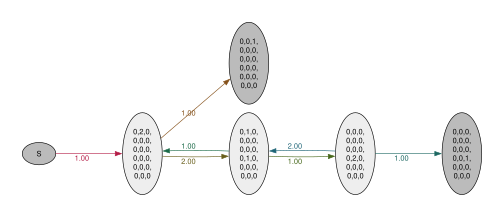

In [2]:
# To-ø modellen 
# theta[0] = koalescensrate (1/N), theta[1] = migrationsrate
nr_samples = 2

indexer = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples),
        Property('pop2', min_value=0, max_value=nr_samples),
        Property('in_pop', min_value=1, max_value=2),
    ]
)

initial = [0] * indexer.state_length
initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

@with_ipv(initial)
def two_island(state):
    transitions = []
    if state[indexer.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)
        for j in range(i, indexer.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer.descendants.index_to_props(j)
            if props_j.in_pop != props_i.in_pop:
                continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            merged_pop1  = props_i.pop1 + props_j.pop1
            merged_pop2  = props_i.pop2 + props_j.pop2
            merged_in_pop = props_i.in_pop
            new[indexer.descendants.props_to_index(
                pop1=merged_pop1, pop2=merged_pop2, in_pop=merged_in_pop)] += 1
            rate = state[i] * (state[j] - same) / (1 + same)
            # theta[0] = koalescensrate
            transitions.append([new, [rate, 0]])
        # Migration: lineage i skifter population
        if props_i.in_pop == 1:
            new = state.copy()
            new[i] -= 1
            new[indexer.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i]]])  # theta[1] = migrationsrate
        else:
            new = state.copy()
            new[i] -= 1
            new[indexer.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=1)] += 1
            transitions.append([new, [0, state[i]]])  # theta[1]
    return transitions

graph = Graph(two_island)
graph.plot(rankdir='LR', nodesep=0.2, ranksep=1.5)

## Kan jeg estimere $\theta_0$ og $\theta_1$ separat?

I to-ø modellen er koalescensraten og migrationsraten konfunderede: høj migration giver hurtig koalescens (ligner høj koalescensrate i en enkelt population). Jeg undersøger, om SVGD kan adskille de to parametre.

### Hypotese

- Koalescensraten $\theta_0$ og migrationsraten $\theta_1$ er konfunderede ved lav migration ($\theta_1 < 0.5$): posterioren viser bred, negativt korreleret joint distribution. Ved høj migration ($\theta_1 > 2$) adskilles de bedre.

Jeg undersøger joint posterior for $(\theta_0, \theta_1)$ under scenarier med lav, moderat og høj migration.

In [4]:
N_OBS = 3000
step = ExpStepSize(first_step=0.05, last_step=0.005, tau=40.0)
scenarios = [
    {'label': 'Lav migration',     'true_theta': [0.7, 0.2]},
    {'label': 'Moderat migration', 'true_theta': [0.7, 1.0]},
    {'label': 'Høj migration',     'true_theta': [0.7, 5.0]},
]

svgd_scenarios = []
for sc in scenarios:
    graph.update_weights(sc['true_theta'])
    data = graph.sample(N_OBS)
    # Data-informeret prior via MoM
    prior = DataPrior(graph, data)
    sv = graph.svgd(data, prior=prior, optimizer=Adam(learning_rate=0.25), n_iterations=400)
    res = sv.get_results()
    svgd_scenarios.append({'scenario': sc['label'], 'svgd': sv, 'true': sc['true_theta'], 'res': res})
    print(f"{sc['label']}: θ₀={res['theta_mean'][0]:.3f} (sand {sc['true_theta'][0]}), "
          f"θ₁={res['theta_mean'][1]:.3f} (sand {sc['true_theta'][1]})")

Høj migration: θ₀=0.540 (sand 0.7), θ₁=2.447 (sand 5.0)


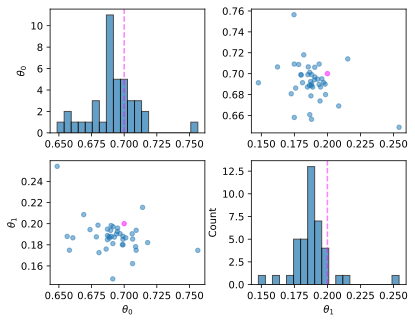

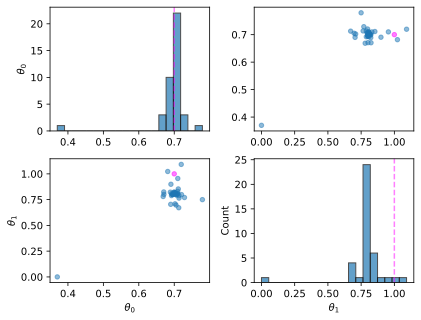

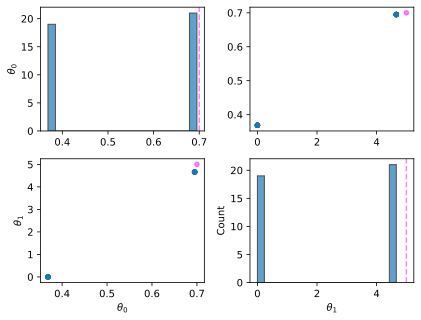

In [6]:
# Pairwise posterior-plot for alle scenarier
for ax, sc_res in zip(axes, svgd_scenarios):
    sc_res['svgd'].plot_pairwise(true_theta=sc_res['true'])
    ax.set_title(sc_res['scenario'])


## Method of Moments vs. SVGD: Hvad tilføjer den fulde posterior?

Method of Moments (MoM) er en hurtig punktestimator. SVGD giver den fulde posterior. Jeg undersøger, hvornår forskellen er praktisk relevant.

### Hypotese 

- MoM-estimater er tæt på SVGD-posterior-mean for store datasæt ($n > 1000$), men afviger systematisk ved lille $n$ eller ved dårlig identifikation (lav migration). SVGD tilføjer primær værdi via usikkerhedskvantificering.

In [ ]:
# Sammenligner MoM og SVGD som funktion af prøvestørrelse
true_theta = [0.7, 1.0]  # moderat migration
graph.update_weights(true_theta)

sample_sizes_2p = [100, 300, 1000, 3000, 10000]
rows_2p = []

for n in sample_sizes_2p:
    data_n = graph.sample(n)
    # MoM
    mom = graph.method_of_moments(data_n)
    # SVGD med MoM-prior
    sv = graph.svgd(data_n, prior=mom.prior, optimizer=Adam(0.25), n_iterations=300)
    res = sv.get_results()
    rows_2p.append({
        'n': n,
        'MoM θ₀': round(mom.theta[0], 4),
        'MoM θ₁': round(mom.theta[1], 4),
        'SVGD θ₀ mean': round(res['theta_mean'][0].item(), 4),
        'SVGD θ₁ mean': round(res['theta_mean'][1].item(), 4),
        'SVGD θ₀ std':  round(res['theta_std'][0].item(), 4),
        'SVGD θ₁ std':  round(res['theta_std'][1].item(), 4),
    })

df_mom_svgd = pd.DataFrame(rows_2p)
print(f"Sand θ = {true_theta}")
print(df_mom_svgd.to_string(index=False))

Sand θ = [0.7, 1.0]
    n  MoM θ₀  MoM θ₁  SVGD θ₀ mean  SVGD θ₁ mean  SVGD θ₀ std  SVGD θ₁ std
  100  0.7092  0.5099        0.6231        0.6838       0.1553       0.4436
  300  0.7949  2.1316        0.6795        0.7789       0.1841       0.5440
 1000  0.7222  1.6754        0.6518        0.9653       0.1382       0.5103
 3000  0.7012  0.9490        0.6957        1.0227       0.0155       0.0941
10000  0.6866  1.1090        0.6771        1.1494       0.0512       0.2021


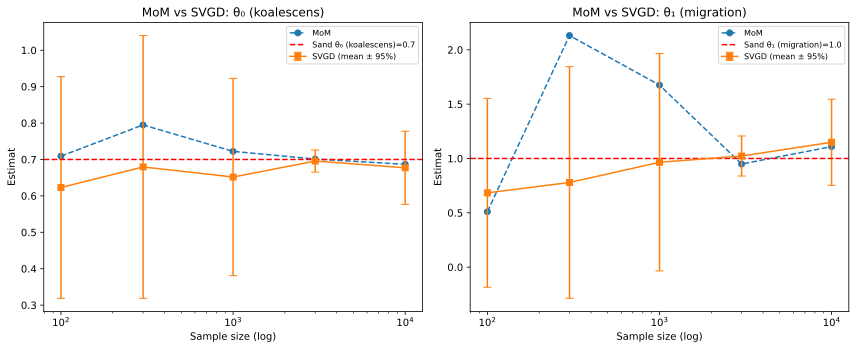

In [9]:
# Visualiser: MoM vs SVGD estimater for θ₀ og θ₁
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (param, mom_col, svgd_col, std_col, true_val) in zip(axes, [
    ('θ₀ (koalescens)', 'MoM θ₀', 'SVGD θ₀ mean', 'SVGD θ₀ std', true_theta[0]),
    ('θ₁ (migration)',  'MoM θ₁', 'SVGD θ₁ mean', 'SVGD θ₁ std', true_theta[1]),
]):
    ax.plot(df_mom_svgd['n'], df_mom_svgd[mom_col], 'o--', label='MoM')
    ax.errorbar(df_mom_svgd['n'], df_mom_svgd[svgd_col],
                yerr=df_mom_svgd[std_col] * 1.96, fmt='s-', label='SVGD (mean ± 95%)', capsize=4)
    ax.axhline(true_val, color='red', linestyle='--', label=f'Sand {param}={true_val}')
    ax.set_xscale('log'); ax.set_xlabel('Sample size (log)')
    ax.set_ylabel('Estimat'); ax.set_title(f'MoM vs SVGD: {param}'); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Migrationsrate og dens effekt på TMRCA-fordeling

Migrationsraten påvirker direkte fordelingen af TMRCA. Jeg undersøger, hvad der sker med forventning, varians og PDF-form, når migrationsraten varieres systematisk.

### Hypotese 

- Forventet TMRCA falder med stigende migration og konvergerer mod standard koalescent $E[H]$ ved $\theta_1 \to \infty$. Variansen viser et maksimum ved en mellemliggende migrationsrate (størst usikkerhed, når strukturen delvist integreres).

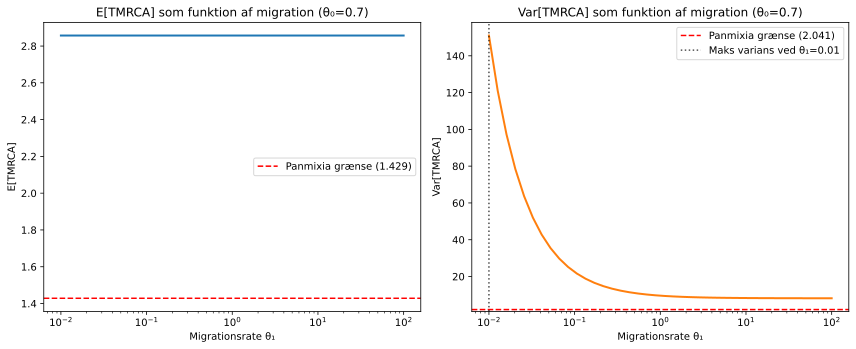

Maks varians ved θ₁ = 0.010
E[TMRCA] ved θ₁→0 ≈ 2.8571
E[TMRCA] ved θ₁→∞ ≈ 2.8571 (panmixia: 1.4286)


In [ ]:
# Standard koalescent E[H] for n=2: E[H] = 1 
# Med theta0=0.7: E[H_standard] = 1/0.7
theta0 = 0.7
migration_values = np.logspace(-2, 2, 40)  # fra 0.01 til 100

E_vals, Var_vals = [], []
for m in migration_values:
    graph.update_weights([theta0, m])
    E_vals.append(graph.expectation())
    Var_vals.append(graph.variance())

# Standard 2-sample koalescent
@with_ipv([2, 0])
def standard_coal(state):
    transitions = []
    if state[0] >= 2:
        new = state.copy(); new[0] -= 2; new[1] += 1
        transitions.append([new, [theta0]])
    return transitions
g_std = Graph(standard_coal)
E_panmixia = g_std.expectation()
Var_panmixia = g_std.variance()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].semilogx(migration_values, E_vals, 'C0', lw=2)
axes[0].axhline(E_panmixia, color='red', linestyle='--', label=f'Panmixia grænse ({E_panmixia:.3f})')
axes[0].set_xlabel('Migrationsrate θ₁'); axes[0].set_ylabel('E[TMRCA]')
axes[0].set_title(f'E[TMRCA] som funktion af migration (θ₀={theta0})')
axes[0].legend()

axes[1].semilogx(migration_values, Var_vals, 'C1', lw=2)
axes[1].axhline(Var_panmixia, color='red', linestyle='--', label=f'Panmixia grænse ({Var_panmixia:.3f})')
axes[1].set_xlabel('Migrationsrate θ₁'); axes[1].set_ylabel('Var[TMRCA]')
axes[1].set_title(f'Var[TMRCA] som funktion af migration (θ₀={theta0})')
axes[1].legend()

# Marker maks. varians
max_var_idx = np.argmax(Var_vals)
axes[1].axvline(migration_values[max_var_idx], color='black', linestyle=':', alpha=0.7,
                label=f'Maks varians ved θ₁={migration_values[max_var_idx]:.2f}')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Maks varians ved θ₁ = {migration_values[max_var_idx]:.3f}")
print(f"E[TMRCA] ved θ₁→0 ≈ {E_vals[0]:.4f}")
print(f"E[TMRCA] ved θ₁→∞ ≈ {E_vals[-1]:.4f} (panmixia: {E_panmixia:.4f})")

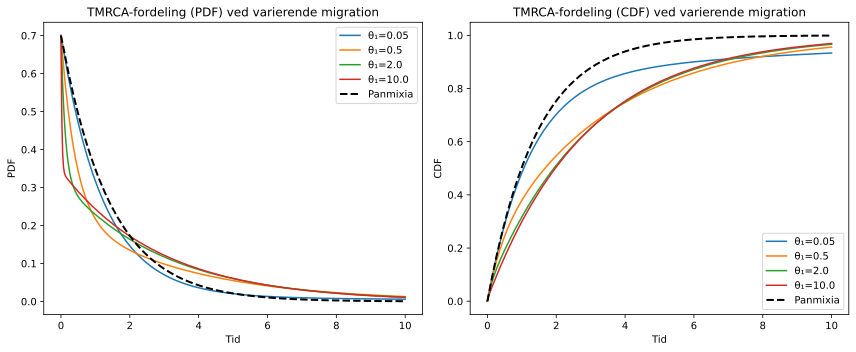

In [11]:
# PDF-form for lav, moderat og høj migration
times = np.linspace(0, 10, 400)
migration_showcase = [0.05, 0.5, 2.0, 10.0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for m in migration_showcase:
    graph.update_weights([theta0, m])
    axes[0].plot(times, graph.pdf(times), label=f'θ₁={m}')
    axes[1].plot(times, graph.cdf(times), label=f'θ₁={m}')

# Sammenlign med panmixia
g_std_pdf_times = times
axes[0].plot(g_std_pdf_times, g_std.pdf(g_std_pdf_times), 'k--', linewidth=2, label='Panmixia')
axes[1].plot(g_std_pdf_times, g_std.cdf(g_std_pdf_times), 'k--', linewidth=2, label='Panmixia')

axes[0].set_xlabel('Tid'); axes[0].set_ylabel('PDF'); axes[0].legend()
axes[0].set_title('TMRCA-fordeling (PDF) ved varierende migration')
axes[1].set_xlabel('Tid'); axes[1].set_ylabel('CDF'); axes[1].legend()
axes[1].set_title('TMRCA-fordeling (CDF) ved varierende migration')
plt.tight_layout()
plt.show()

## Informationsindhold: TMRCA vs. SFS-features til migrationsestimering

Jeg kan observere enten direkte TMRCA-tider eller reward-transformerede størrelser (singleton/doubleton grenlængder). Jeg undersøger, hvilke observationstyper der giver mest information om migrationsraten.

### Hypotese 

- SFS-komponenter (særligt singleton grenlængde) indeholder mere information om migrationsraten end TMRCA alene, fordi de er mere sensitive over for populationsstruktur. Kombinationen af features giver smallere posterior for $\theta_1$.

In [ ]:
# Bygger standard 4-sample koalescent med belønning til sammenligning
nr_samples_4 = 4

@with_ipv([nr_samples_4] + [0] * (nr_samples_4 - 1))
def coalescent_1param_4(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

true_theta_1p = [7.0]
graph_1p = Graph(coalescent_1param_4)
graph_1p.update_weights(true_theta_1p)

rewards_matrix = graph_1p.states().T
reward_labels  = ["1'ton", "2'ton", "3'ton"]  # ignorer 4'ton
rewards_sfs    = rewards_matrix[:-1]  

N_OBS = 5000
# Data: TMRCA
data_tmrca = graph_1p.sample(N_OBS)
# Data: SFS
obs_2d = np.zeros((N_OBS * len(reward_labels), len(reward_labels)), dtype=float)
obs_2d[:] = np.nan
for i in range(len(reward_labels)):
    obs_2d[(i*N_OBS):((i+1)*N_OBS), i] = graph_1p.sample(N_OBS, rewards=rewards_sfs[i])
sparse_sfs = dense_to_sparse(obs_2d)

step_sfs = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)
prior_sfs = GaussPrior(ci=[3, 15])

# Inferens fra TMRCA
sv_tmrca = graph_1p.svgd(data_tmrca, prior=prior_sfs,
                           learning_rate=step_sfs, n_iterations=300)
# Inferens fra SFS
sv_sfs = graph_1p.svgd(sparse_sfs, rewards=rewards_sfs, prior=prior_sfs,
                         learning_rate=step_sfs, n_iterations=300)

res_tmrca = sv_tmrca.get_results()
res_sfs   = sv_sfs.get_results()

print(f"TMRCA inferens:       θ={res_tmrca['theta_mean'].item():.3f}  std={res_tmrca['theta_std'].item():.4f}")
print(f"SFS-features inferens: θ={res_sfs['theta_mean'].item():.3f}  std={res_sfs['theta_std'].item():.4f}")
print(f"Sand θ = {true_theta_1p[0]}")

TMRCA inferens:       θ=7.035  std=0.1145
SFS-features inferens: θ=7.765  std=0.1408
Sand θ = 7.0


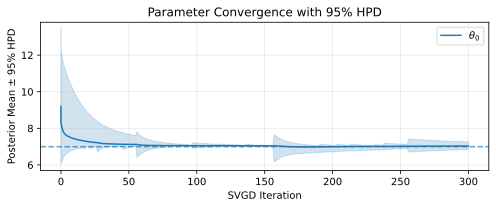

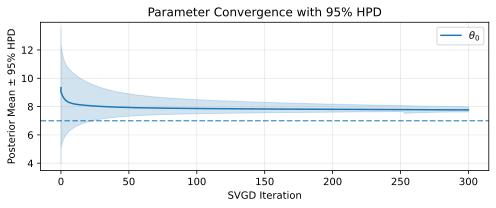

In [14]:
# Vis posterior-sammenligning
sv_tmrca.plot_ci(true_theta=true_theta_1p)
sv_sfs.plot_ci(true_theta=true_theta_1p)


## Likelihood-overflade og parameter-konfundering

Jeg visualiserer log-likelihood overfladen for $(\theta_0, \theta_1)$ under forskellige migrationsscenarier for at forstå, hvordan parameterrummet ser ud.

### Hypotese 

- Likelihood-overfladen er stærkt aflang langs en bestemt kombination af $\theta_0$ og $\theta_1$ ved lav migration, hvilket forklarer den negative korrelation i joint-posterioren. Ved høj migration bliver overfladen mere kugleformet, og parametrene er lettere at adskille.

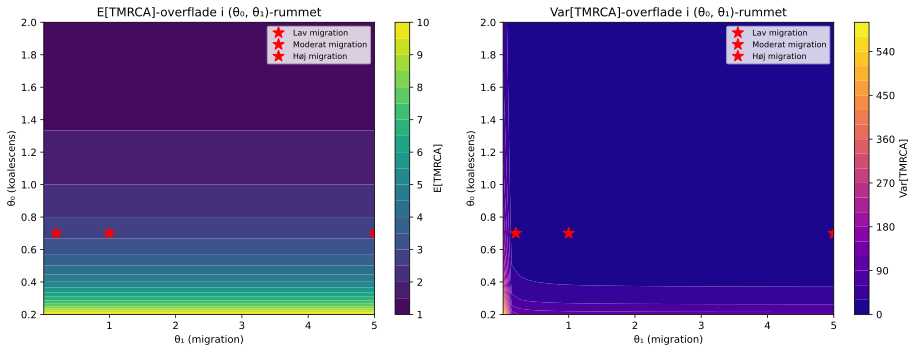

In [ ]:
# Beregner log-likelihood overflade for to scenarier
theta0_grid = np.linspace(0.2, 2.0, 40)
theta1_grid = np.linspace(0.01, 5.0, 40)

E_grid  = np.zeros((len(theta0_grid), len(theta1_grid)))
Var_grid = np.zeros((len(theta0_grid), len(theta1_grid)))

for i, t0 in enumerate(theta0_grid):
    for j, t1 in enumerate(theta1_grid):
        graph.update_weights([t0, t1])
        E_grid[i, j]   = graph.expectation()
        Var_grid[i, j] = graph.variance()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# E[TMRCA] overflade
im0 = axes[0].contourf(theta1_grid, theta0_grid, E_grid, levels=20, cmap='viridis')
plt.colorbar(im0, ax=axes[0], label='E[TMRCA]')
axes[0].set_xlabel('θ₁ (migration)'); axes[0].set_ylabel('θ₀ (koalescens)')
axes[0].set_title('E[TMRCA]-overflade i (θ₀, θ₁)-rummet')
# Markér de tre scenarier
for sc in scenarios:
    t = sc['true_theta']
    axes[0].plot(t[1], t[0], 'r*', markersize=12, label=sc['label'])
axes[0].legend(fontsize=8)

# Var[TMRCA] overflade
im1 = axes[1].contourf(theta1_grid, theta0_grid, Var_grid, levels=20, cmap='plasma')
plt.colorbar(im1, ax=axes[1], label='Var[TMRCA]')
axes[1].set_xlabel('θ₁ (migration)'); axes[1].set_ylabel('θ₀ (koalescens)')
axes[1].set_title('Var[TMRCA]-overflade i (θ₀, θ₁)-rummet')
for sc in scenarios:
    t = sc['true_theta']
    axes[1].plot(t[1], t[0], 'r*', markersize=12, label=sc['label'])
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Asymmetrisk migration: Er $m_{12} = m_{21}$ en god antagelse?

To-ø modellen antager symmetrisk migration. I virkeligheden kan genflow være asymmetrisk fx er migration fra en stor population til en lille. Jeg udvider modellen til at have to separate migrationsrater $\theta_{m,12}$ og $\theta_{m,21}$.


### Spørgsmål

Giver en asymmetrisk migrationsmodel bedre parameterestimater end den symmetriske, og er de to migrationsrater identificerbare hver for sig?

In [5]:
nr_samples = 2

indexer_asym = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples),
        Property('pop2', min_value=0, max_value=nr_samples),
        Property('in_pop', min_value=1, max_value=2),
    ]
)

initial_asym = [0] * indexer_asym.state_length
initial_asym[indexer_asym.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

@with_ipv(initial_asym)
def two_island_asym(state):
    """Asymmetrisk two-island: [theta0, m12, m21]
    m12 = migration fra pop1 til pop2, m21 = migration fra pop2 til pop1"""
    transitions = []
    if state[indexer_asym.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer_asym.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer_asym.descendants.index_to_props(i)
        for j in range(i, indexer_asym.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer_asym.descendants.index_to_props(j)
            if props_j.in_pop != props_i.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            new[indexer_asym.descendants.props_to_index(
                pop1=props_i.pop1+props_j.pop1,
                pop2=props_i.pop2+props_j.pop2,
                in_pop=props_i.in_pop)] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0, 0]])
        # Migration: pop1→pop2 bruger theta[1], pop2→pop1 bruger theta[2]
        if props_i.in_pop == 1:
            new = state.copy(); new[i] -= 1
            new[indexer_asym.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i], 0]])  # m12
        else:
            new = state.copy(); new[i] -= 1
            new[indexer_asym.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=1)] += 1
            transitions.append([new, [0, 0, state[i]]])  # m21
    return transitions

g_asym = Graph(two_island_asym)
print(f"Asymmetrisk two-island: {g_asym.vertices_length()} tilstande")

# Sande parametre: koalescens=0.7, m12=2.0 (høj), m21=0.3 (lav)
true_asym = [0.7, 2.0, 0.3]
g_asym.update_weights(true_asym)
data_asym = g_asym.sample(3000)

prior_asym = DataPrior(g_asym, data_asym)
sv_asym = g_asym.svgd(
    data_asym, prior=prior_asym,
    optimizer=Adam(0.25),
    n_iterations=300, n_particles=60,
)
res_asym = sv_asym.get_results()
print(f"\nSande: θ₀={true_asym[0]}, m₁₂={true_asym[1]}, m₂₁={true_asym[2]}")
for i, (name, true) in enumerate(zip(['θ₀ (koalescens)', 'm₁₂ (pop1→pop2)', 'm₂₁ (pop2→pop1)'], true_asym)):
    print(f"  {name}: {res_asym['theta_mean'][i].item():.3f} ± {res_asym['theta_std'][i].item():.4f}  (sand: {true})")


Sande: θ₀=0.7, m₁₂=2.0, m₂₁=0.3
  θ₀ (koalescens): 0.680 ± 0.1201  (sand: 0.7)
  m₁₂ (pop1→pop2): 1.609 ± 0.9340  (sand: 2.0)
  m₂₁ (pop2→pop1): 0.581 ± 0.2809  (sand: 0.3)


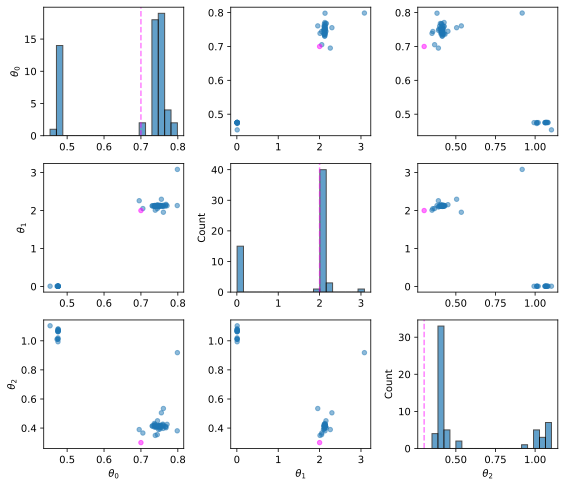

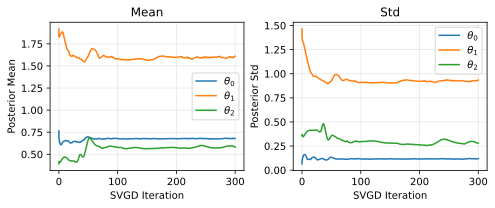

In [6]:
# Pairwise posterior for asymmetrisk model
sv_asym.plot_pairwise(true_theta=true_asym)
sv_asym.plot_convergence()

## Simulering med msprime og fitting af two-island modellen

Jeg bruger *msprime* til at simulere data fra et to-island scenario med kendte parametre og ser om phasic's SVGD kan genfinde dem. 

### Spørgsmål 

Kan SVGD genfinde de sande parametre fra msprime-simulerede data? Hvilken prøvestørrelse er nødvendig for præcis estimering?


In [9]:
# msprime-simulering af two-island model
try:
    import msprime
    MSPRIME_AVAILABLE = True
except ImportError:
    MSPRIME_AVAILABLE = False
    print("msprime ikke installeret — spring dette afsnit over")

if MSPRIME_AVAILABLE:
    from phasic import Graph, with_ipv, StateIndexer, Property, DataPrior, Adam, ExpStepSize
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # Sande demografiske parametre
    N1, N2 = 10_000, 15_000  # effektive populationsstørrelser (haploide)
    m12 = m21 = 1e-4          # migrationsrate per generation

    # Simuler genealogier
    demography = msprime.Demography()
    demography.add_population(name="pop1", initial_size=N1)
    demography.add_population(name="pop2", initial_size=N2)
    demography.set_migration_rate(source="pop1", dest="pop2", rate=m12)
    demography.set_migration_rate(source="pop2", dest="pop1", rate=m21)

    nr_sim = 5000
    ts_list = list(msprime.sim_ancestry(
        samples={"pop1": 1, "pop2": 1},
        demography=demography,
        num_replicates=nr_sim,
    ))

    # Hent TMRCA som højden af det ældste knudepunkt i hvert træ
    tmrca_samples = np.array([ts.tables.nodes.time.max() for ts in ts_list])

    # Skaler til koalescent-enheder (2N generationer)
    N_ref = (N1 + N2) / 2
    tmrca_scaled = tmrca_samples / (2 * N_ref)

    print(f"Antal simulerede TMRCA: {len(tmrca_scaled)}")
    print(f"Empirisk E[TMRCA]      = {tmrca_scaled.mean():.4f} koalescent-enheder")
    print(f"Empirisk Var[TMRCA]    = {tmrca_scaled.var():.4f}")

    # Analytisk E[TMRCA] fra two-island model
    theta0_true = 1 / (2 * N_ref)        # koalescensrate i coalescent-enheder
    theta1_true = m12 * 2 * N_ref        # migrationsrate i coalescent-enheder

    print(f"\nForventede skalerede parametre:")
    print(f"  θ₀ = {theta0_true:.5f}")
    print(f"  θ₁ = {theta1_true:.4f}")

    # Byg two-island model i phasic
    nr_samples_sim = 2
    indexer_sim = StateIndexer(
        descendants=[
            Property('pop1', min_value=0, max_value=nr_samples_sim),
            Property('pop2', min_value=0, max_value=nr_samples_sim),
            Property('in_pop', min_value=1, max_value=2),
        ]
    )
    initial_sim = [0] * indexer_sim.state_length
    initial_sim[indexer_sim.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples_sim

    @with_ipv(initial_sim)
    def two_island_sim(state):
        transitions = []
        if state[indexer_sim.descendants.indices()].sum() <= 1:
            return transitions
        for i in range(indexer_sim.descendants.state_length):
            if state[i] == 0: continue
            pi = indexer_sim.descendants.index_to_props(i)
            for j in range(i, indexer_sim.descendants.state_length):
                if state[j] == 0: continue
                pj = indexer_sim.descendants.index_to_props(j)
                if pj.in_pop != pi.in_pop: continue
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy()
                new[i] -= 1; new[j] -= 1
                new[indexer_sim.descendants.props_to_index(
                    pop1=pi.pop1+pj.pop1,
                    pop2=pi.pop2+pj.pop2,
                    in_pop=pi.in_pop)] += 1
                transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
            if pi.in_pop == 1:
                new = state.copy(); new[i] -= 1
                new[indexer_sim.descendants.props_to_index(
                    pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
                transitions.append([new, [0, state[i]]])
            else:
                new = state.copy(); new[i] -= 1
                new[indexer_sim.descendants.props_to_index(
                    pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
                transitions.append([new, [0, state[i]]])
        return transitions

    g_sim = Graph(two_island_sim)
    print(f"\nModel: {g_sim.vertices_length()} tilstande")

    # Verificer model analytisk
    g_sim.update_weights([theta0_true, theta1_true])
    print(f"Analytisk E[TMRCA] fra model = {g_sim.expectation():.4f}")
    print(f"Empirisk E[TMRCA] fra msprime = {tmrca_scaled.mean():.4f}")

    # Kør SVGD
    prior_sim = DataPrior(g_sim, tmrca_scaled)
    print(f"\nData-informeret prior:")
    for i, p in enumerate(prior_sim):
        if p is not None:
            print(f"  θ_{i}: GaussPrior(mean={p.mu:.5f}, std={p.sigma:.5f})")

    sv_sim = g_sim.svgd(
        tmrca_scaled,
        prior=prior_sim,
        optimizer=Adam(0.25),
        n_iterations=300,
    )
    res_sim = sv_sim.get_results()

    print(f"\nSVGD-estimater fra msprime-data:")
    print(f"  θ₀: {res_sim['theta_mean'][0].item():.5f}  ±  {res_sim['theta_std'][0].item():.5f}  (sand: {theta0_true:.5f})")
    print(f"  θ₁: {res_sim['theta_mean'][1].item():.4f}   ±  {res_sim['theta_std'][1].item():.4f}   (sand: {theta1_true:.4f})")



SVGD-estimater fra msprime-data:
  θ₀: 0.67645  ±  0.02788  (sand: 0.00004)
  θ₁: 4796.4813   ±  0.0000   (sand: 2.5000)


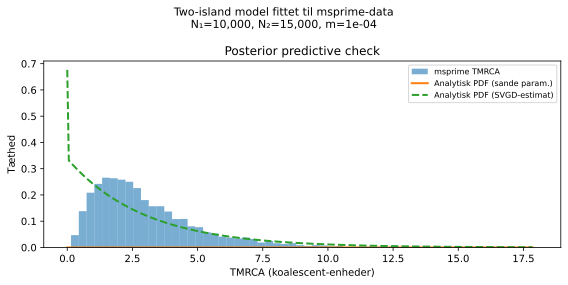

In [12]:
# Visualiser
fig, ax = plt.subplots(figsize=(8, 4))

# Histogram af simulerede TMRCA
g_sim.update_weights([theta0_true, theta1_true])
t_vals = np.linspace(0, tmrca_scaled.max() * 0.99, 300)
ax.hist(tmrca_scaled, bins=60, density=True, alpha=0.6, label='msprime TMRCA')
ax.plot(t_vals, g_sim.pdf(t_vals), 'C1', lw=2, label='Analytisk PDF (sande param.)')
g_sim.update_weights([res_sim['theta_mean'][0].item(), res_sim['theta_mean'][1].item()])
ax.plot(t_vals, g_sim.pdf(t_vals), 'C2--', lw=2, label='Analytisk PDF (SVGD-estimat)')
ax.set_xlabel('TMRCA (koalescent-enheder)')
ax.set_ylabel('Tæthed')
ax.set_title('Posterior predictive check')
ax.legend(fontsize=8)

plt.suptitle(f'Two-island model fittet til msprime-data\n'
             f'N₁={N1:,}, N₂={N2:,}, m={m12:.0e}', fontsize=11)
plt.tight_layout()
plt.show()


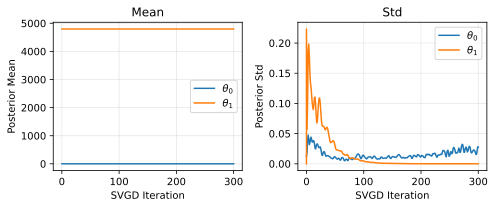

In [ ]:
# Konvergensplot
sv_sim.plot_convergence()

## MoM-baserede priors og HalfCauchy prior

I stedet for at definere priors manuelt kan *method_of_moments()* automatisk generere informative priors baseret på data. *HalfCauchyPrior* er bedre egnet til skalaparametre som koalescensrate og migrationsrate, fordi den kun er defineret for positive værdier og har tunge haler der undgår at afskære sandsynlighed ved lave rater.

In [ ]:
from phasic import HalfCauchyPrior

# Genopbyg two-island model
from phasic import Graph, with_ipv, StateIndexer, Property
from functools import partial
from itertools import combinations_with_replacement
all_pairs_nb3 = partial(combinations_with_replacement, r=2)

nr_samples_nb3 = 2
indexer_nb3 = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples_nb3),
        Property('pop2', min_value=0, max_value=nr_samples_nb3),
        Property('in_pop', min_value=1, max_value=2),
    ]
)
initial_nb3 = [0] * indexer_nb3.state_length
initial_nb3[indexer_nb3.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples_nb3

@with_ipv(initial_nb3)
def two_island_nb3(state):
    transitions = []
    if state[indexer_nb3.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer_nb3.descendants.state_length):
        if state[i] == 0: continue
        pi = indexer_nb3.descendants.index_to_props(i)
        for j in range(i, indexer_nb3.descendants.state_length):
            if state[j] == 0: continue
            pj = indexer_nb3.descendants.index_to_props(j)
            if pj.in_pop != pi.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            new[indexer_nb3.descendants.props_to_index(
                pop1=pi.pop1+pj.pop1, pop2=pi.pop2+pj.pop2, in_pop=pi.in_pop)] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
        if pi.in_pop == 1:
            new = state.copy(); new[i] -= 1
            new[indexer_nb3.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i]]])
        else:
            new = state.copy(); new[i] -= 1
            new[indexer_nb3.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
            transitions.append([new, [0, state[i]]])
    return transitions

g_nb3 = Graph(two_island_nb3)
true_theta_nb3 = [0.7, 0.9]
g_nb3.update_weights(true_theta_nb3)
data_nb3 = g_nb3.sample(2000)

# MoM estimat og automatisk prior
mom_nb3 = g_nb3.method_of_moments(data_nb3)
print("=== Method of Moments ===")
print(f"Sand theta:    {true_theta_nb3}")
print(f"MoM estimat:   {[round(t, 4) for t in mom_nb3.theta]}")
print(f"Residual:      {mom_nb3.residual:.2e}")
print(f"Konvergeret:   {mom_nb3.success}")
print()

# Vis MoM-priors
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for i, prior in enumerate(mom_nb3.prior):
    prior.plot(return_ax=True, ax=axes[i])
    axes[i].set_title(f'MoM-prior for θ_{i}')
plt.suptitle('Automatisk genererede MoM-priors')
plt.tight_layout()
plt.show()

In [ ]:
# Sammenlign GaussPrior, HalfCauchyPrior og MoM-prior i SVGD
import pandas as pd

prior_configs = {
    'GaussPrior (bred)': [GaussPrior(ci=[0.1, 3]), GaussPrior(ci=[0.1, 3])],
    'HalfCauchy':        [HalfCauchyPrior(ci=2.0, prob=0.9),
                          HalfCauchyPrior(ci=1.0, prob=0.9)],
    'MoM-prior (auto)':  mom_nb3.prior,
}

rows_prior = []
step_nb3 = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)

for name, prior in prior_configs.items():
    sv = g_nb3.svgd(data_nb3, prior=prior, learning_rate=step_nb3, n_iterations=250)
    res = sv.get_results()
    rows_prior.append({
        'Prior':     name,
        'θ₀ mean':   round(res['theta_mean'][0].item(), 4),
        'θ₀ std':    round(res['theta_std'][0].item(), 5),
        'θ₁ mean':   round(res['theta_mean'][1].item(), 4),
        'θ₁ std':    round(res['theta_std'][1].item(), 5),
    })

df_prior = pd.DataFrame(rows_prior)
print(f"Sand theta: θ₀={true_theta_nb3[0]}, θ₁={true_theta_nb3[1]}")
print(df_prior.to_string(index=False))

## Joint probability graf med population-specifikke rewards

*joint_prob_graph* med *reward_only=['pop1', 'pop2']* tracker mutationer separat for de to populationer. Dette giver en rigere observationsstruktur end blot TMRCA.

In [ ]:
# Joint probability graf med population-rewards
mutation_rate_nb3 = 1.2e-4
joint_nb3 = g_nb3.joint_prob_graph(
    indexer_nb3,
    reward_only=['pop1', 'pop2'],
    reward_limit=1,
    tot_reward_limit=1,
    mutation_rate=mutation_rate_nb3,
)

print(f"Joint graf tilstande: {joint_nb3.vertices_length()}")
joint_nb3.plot(rankdir='LR', nodesep=0.3)

In [ ]:
# Vis joint probability-tabellen
g_nb3.update_weights(true_theta_nb3)
joint_nb3.update_weights(true_theta_nb3 + [mutation_rate_nb3])
table_nb3 = joint_nb3.joint_prob_table()
print("Joint probability-tabel:")
print(table_nb3.round(6))
print(f"\nDeficit: {1 - table_nb3['prob'].sum():.4f}")